# CO544: Machine Learning and Data Mining
# Lab 1: Python Data Science Toolbox

### E/21/245
### MDHAUSHAN S.K.A.K.



In [ ]:
#importing the nessasary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

### Exercise 01 - Numpy advanced operations

In [ ]:
arr = np.random.randint(0,101,size=20)
print("Original Array is ",arr)

Original Array is  [ 40  72  95  42  68  51  96  20  82  26  29   8  34  12  33  49  82  82
  20 100]


In [ ]:
# adding the boolean indexing
mask = arr > 50
filtered_arr = arr[mask]
print("vlaues that are bigger than 50 = ", filtered_arr)

vlaues that are bigger than 50 =  [ 72  95  68  51  96  82  82  82 100]


In [ ]:
# broadcasting
small = np.arange(5)
large = arr[:20].reshape(4,5)
result = large + small

In [ ]:
print("small arr = " , small)
print("big arr = " , large)
print("result arr with adding both above = " , result)

small arr =  [0 1 2 3 4]
big arr =  [[ 40  72  95  42  68]
 [ 51  96  20  82  26]
 [ 29   8  34  12  33]
 [ 49  82  82  20 100]]
result arr with adding both above =  [[ 40  73  97  45  72]
 [ 51  97  22  85  30]
 [ 29   9  36  15  37]
 [ 49  83  84  23 104]]


In [ ]:
# compute the dot product of two arrays of length 10
a = np.arange(10)
b = np.linspace(0,9,10)
dp = np.dot(a,b)
print("the dot product = ",dp)

the dot product =  285.0


### Exercise 2: Matplotlib Subplots

In [ ]:
x = np.linspace(0, 2*np.pi, 200)
y1 = np.sin(x)
y2 = np.cos(x)

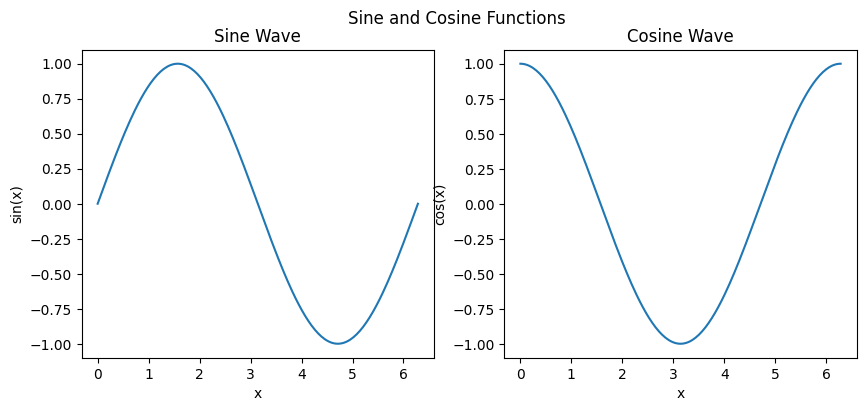

In [ ]:
fig , axes = plt.subplots (1,2, sharex=True,figsize=(10,4))
axes [0]. plot(x, y1)
axes [0]. set( title ="Sine Wave", xlabel="x", ylabel="sin(x)")
axes [1]. plot(x, y2)
axes [1]. set( title ="Cosine Wave", xlabel="x", ylabel="cos(x)")
fig . suptitle ("Sine and Cosine Functions")
plt . savefig ('trig_functions.png')
plt .show()

### Exercise 3: Pandas Cleaning & Preprocessing


In [ ]:
# Load Titanic dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Fare_int
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,32.214366
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,49.693352
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,8.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,14.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,512.000000


In [ ]:
 # impute missing values
# using meadian here
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
# Drop duplicates
df.drop_duplicates(inplace=True)

In [ ]:
# convert and detect outliers in Fare
df['Fare_int'] = df['Fare'].round().astype(int)
Q1 = df['Fare_int'].quantile(0.25)
Q3 = df['Fare_int'].quantile(0.75)
IQR = Q3 - Q1

In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
outliers = df[(df['Fare_int'] < lower_bound) | (df['Fare_int'] > upper_bound)]
print("\nDetected Outliers in Fare:")
print(outliers.head())


Detected Outliers in Fare:
    PassengerId  Survived  Pclass  \
1             2         1       1   
27           28         0       1   
31           32         1       1   
34           35         0       1   
52           53         1       1   

                                                 Name     Sex   Age  SibSp  \
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
27                     Fortune, Mr. Charles Alexander    male  19.0      3   
31     Spencer, Mrs. William Augustus (Marie Eugenie)  female  28.0      1   
34                            Meyer, Mr. Edgar Joseph    male  28.0      1   
52           Harper, Mrs. Henry Sleeper (Myna Haxtun)  female  49.0      1   

    Parch    Ticket      Fare        Cabin Embarked  Fare_int  
1       0  PC 17599   71.2833          C85        C        71  
27      2     19950  263.0000  C23 C25 C27        S       263  
31      0  PC 17569  146.5208          B78        C       147  
34      0  PC 17604   82

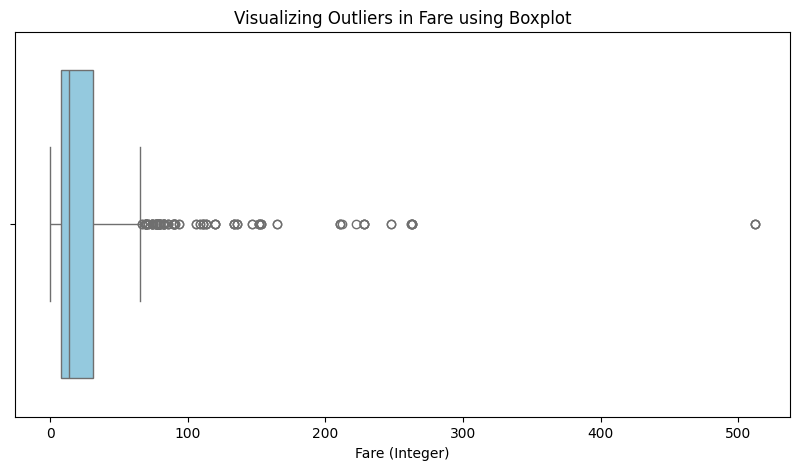

In [ ]:
# Boxplot  drawing to visually see it
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Fare_int'], color='skyblue')

plt.title('Visualizing Outliers in Fare using Boxplot')
plt.xlabel('Fare (Integer)')
plt.show()

removing the outliers that we have

Original data rows: 891
Cleaned data rows: 775
Removed outliers: 116


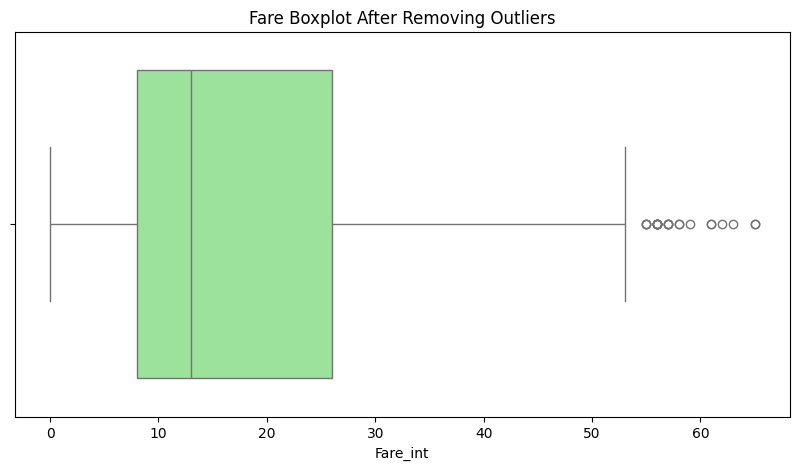

In [ ]:
# create a new dataframe with cleaned values exlduing the outliers
df_cleaned = df[(df['Fare_int'] >= lower_bound) & (df['Fare_int'] <= upper_bound)]

print(f"Original data rows: {len(df)}")
print(f"Cleaned data rows: {len(df_cleaned)}")
print(f"Removed outliers: {len(df) - len(df_cleaned)}")

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_cleaned['Fare_int'], color='lightgreen')
plt.title('Fare Boxplot After Removing Outliers')
plt.show()

In [ ]:
# drop the cabin beacuse it is empty upto 70% total data
df.drop(columns=['Cabin'], inplace=True)

### Exercise 4: Pandas Essentials

In [ ]:
# Create and inspect Series
print("Step 1: Series")
s1 = pd.Series([1, 2, 4, 5])
print("Shape and Index of s1:", s1.shape, s1.index)

Step 1: Series
Shape and Index of s1: (4,) RangeIndex(start=0, stop=4, step=1)


In [ ]:
s2 = pd.Series([1, 2, 4, 5], index=['a', 'b', 'c', 'd'])
print("Series s2 with custom index:\n", s2)

Series s2 with custom index:
 a    1
b    2
c    4
d    5
dtype: int64


In [ ]:
# Build DataFrame and summarize
print("\n Step 2: DataFrames ")
df1 = pd.DataFrame({'name':['Alice', 'Bob', 'Charlie'], 'score':[85, 92, 78]})
df2 = pd.DataFrame(np.random.randn(100, 3), columns=list('ABC'))


 Step 2: DataFrames 


In [ ]:
print("Head of df1:\n", df1.head())
print("\nInfo of df1:")
df1.info()
print("\nStatistics of df2:\n", df2.describe())

Head of df1:
       name  score
0    Alice     85
1      Bob     92
2  Charlie     78

Info of df1:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    3 non-null      object
 1   score   3 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 180.0+ bytes

Statistics of df2:
                 A           B           C
count  100.000000  100.000000  100.000000
mean     0.129377   -0.083296    0.124352
std      0.926351    0.956715    0.928569
min     -2.344675   -2.143245   -2.129914
25%     -0.416787   -0.708341   -0.514913
50%      0.063515   -0.140543    0.087022
75%      0.725084    0.490041    0.841445
max      2.854707    2.320389    2.100398


In [ ]:
# Indexing with loc/iloc, sorting, and dropping
print("\n Step 3: Indexing & Sorting ")
print("Score of Alice (loc[0]):", df1.loc[0, 'score'])
print("3rd row of df2 (iloc[2]):\n", df2.iloc[2])


 Step 3: Indexing & Sorting 
Score of Alice (loc[0]): 85
3rd row of df2 (iloc[2]):
 A    0.900444
B   -0.092547
C   -0.631194
Name: 2, dtype: float64


In [ ]:
df2_sorted = df2.sort_values('A', ascending=False)
df2_no_b = df2_sorted.drop(['B'], axis=1)
print("\nSorted df2 without column B (head):\n", df2_no_b.head())


Sorted df2 without column B (head):
            A         C
73  2.854707  1.191794
43  2.459327  0.522974
90  2.171583 -0.125492
21  1.885016  0.707893
85  1.671412  1.843903


In [ ]:
# Handle missing data
print("\n Step 4: Missing Data")
df_nan = pd.DataFrame({'X':[1, None, 3], 'Y':[None, 2, 3]})
print("Original df with NaNs:\n", df_nan)
print("After dropna():\n", df_nan.dropna())
print("After fillna(0):\n", df_nan.fillna(0))


 Step 4: Missing Data
Original df with NaNs:
      X    Y
0  1.0  NaN
1  NaN  2.0
2  3.0  3.0
After dropna():
      X    Y
2  3.0  3.0
After fillna(0):
      X    Y
0  1.0  0.0
1  0.0  2.0
2  3.0  3.0


In [ ]:
print("\n Step 5: Excel I/O ")
df_weather = pd.read_excel('weather.xlsx')
print("Weather Tail:\n", df_weather.tail())

df_weather['Status'] = 'Updated'
df_weather.to_excel('weather_updated.xlsx', index=False)
print("Updated excel saved as 'weather_updated.xlsx'")


 Step 5: Excel I/O 
Weather Tail:
           Date  MaxTemp_C  MinTemp_C  AvgTemp_C  Precip_mm  WindSpeed_kph  \
361 2024-12-27       29.1       20.2       24.7        0.0           12.4   
362 2024-12-28       30.2       16.3       23.2        5.6           12.9   
363 2024-12-29       25.9       16.2       21.1        4.9           11.0   
364 2024-12-30       27.6       19.2       23.4        0.0           17.9   
365 2024-12-31       30.7       18.3       24.5        0.0            8.4   

     Humidity_pct  
361            59  
362            80  
363            83  
364            65  
365            59  
Updated excel saved as 'weather_updated.xlsx'


### Exercise 5: Loading Open Dataset from UCI Repository

In [ ]:
# Load Wine dataset
wine_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data'
cols = ['Class', 'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash',
        'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols',
        'Proanthocyanins', 'Color_intensity', 'Hue',
        'OD280/OD315_of_diluted_wines', 'Proline']

df_wine = pd.read_csv(wine_url, names=cols)

print("--- Wine Dataset Head (First 10 rows) ---")
print(df_wine.head(10))

# Group by class and calculate mean
print("\n--- Mean Values per Wine Class ---")
wine_means = df_wine.groupby('Class').mean()
print(wine_means)

--- Wine Dataset Head (First 10 rows) ---
   Class  Alcohol  Malic_acid   Ash  Alcalinity_of_ash  Magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   
5      1    14.20        1.76  2.45               15.2        112   
6      1    14.39        1.87  2.45               14.6         96   
7      1    14.06        2.15  2.61               17.6        121   
8      1    14.83        1.64  2.17               14.0         97   
9      1    13.86        1.35  2.27               16.0         98   

   Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26      

### Exercise 6: scikit-learn Iris Dataset (Extended)

In [ ]:
#  Load and preview Iris dataset
iris = datasets.load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
print(" Iris Dataset Head ")
print(df_iris.head())

 Iris Dataset Head 
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


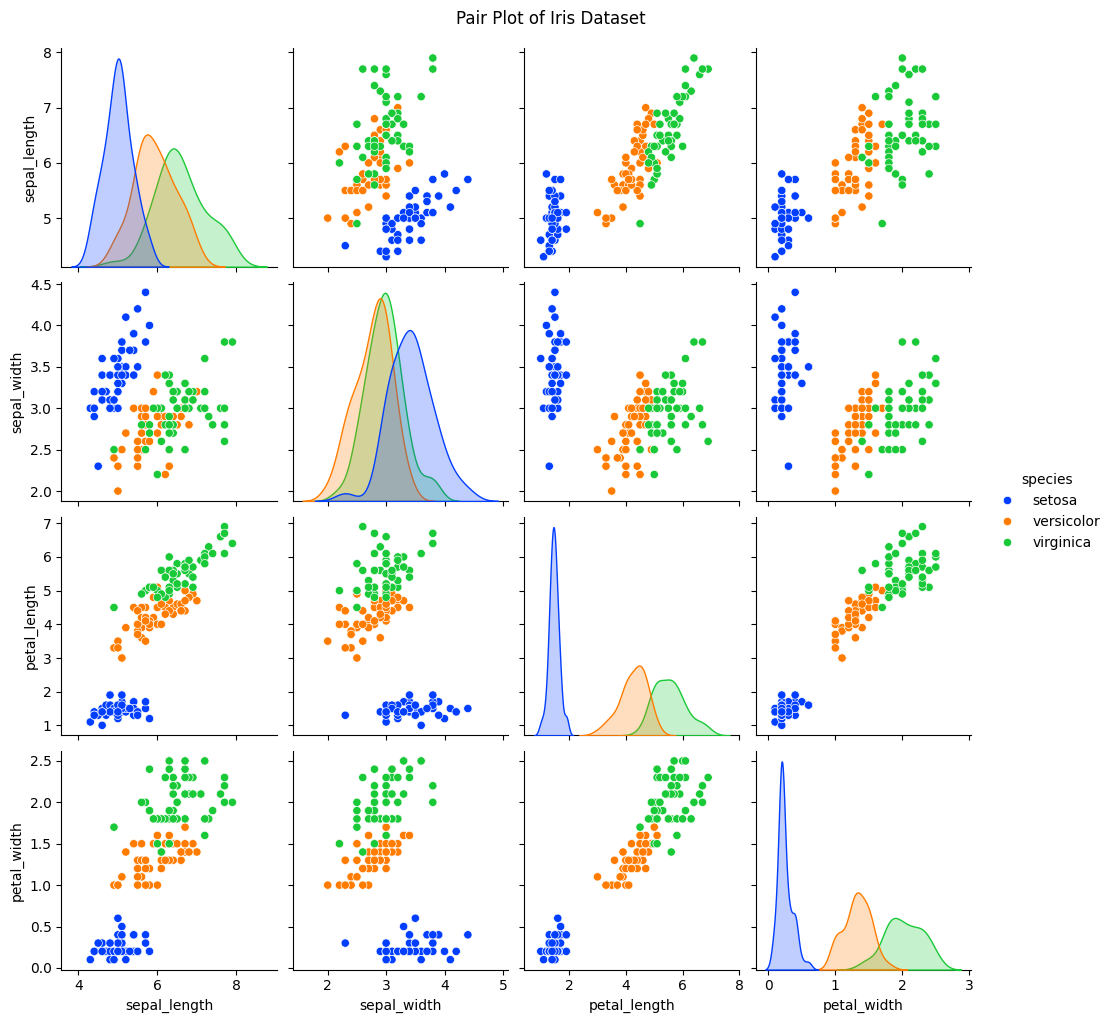

In [ ]:
iris_viz = sns.load_dataset('iris')

# Pairplot
sns.pairplot(iris_viz, hue='species', palette='bright')
plt.suptitle("Pair Plot of Iris Dataset", y=1.02)
plt.show()

#### Insights from the Pair Plot :

The pair plot provides a clear visualization of how the three Iris species are distributed based on their features. I observed that the Setosa species (blue) is perfectly separated from the other two species, especially in petal-related plots. This indicates that petal length and petal width are the most discriminative features for classification. While Versicolor (orange) and Virginica (green) show some overlapping in sepal measurements, they are still mostly distinguishable through their petal dimensions. The strong linear relationship between petal length and width suggests that these features are highly correlated, which explains the high accuracy achieved by the logistic regression model.

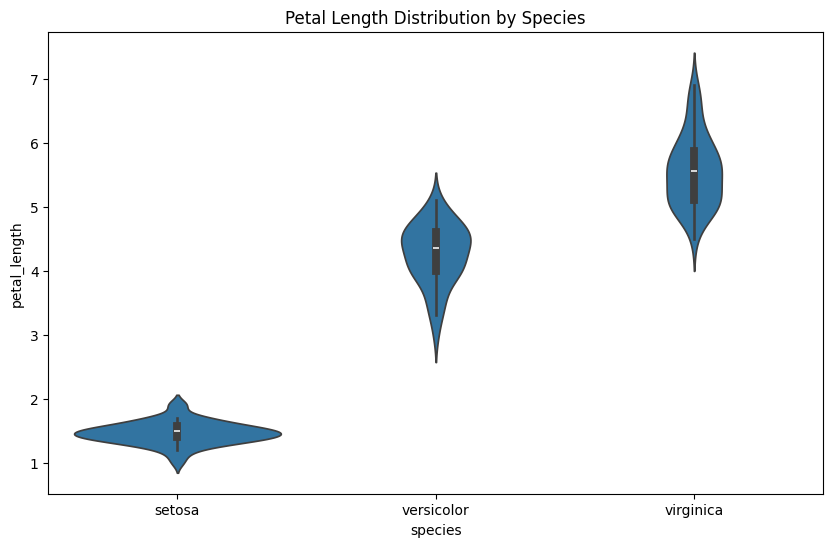

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='species', y='petal_length', data=iris_viz)
plt.title("Petal Length Distribution by Species")
plt.show()

#### Observation from Violin Plot

I created a Violin Plot to analyze the distribution of petal lengths across the three Iris species. The plot shows that Setosa has the shortest and least variable petal length, making it easily distinguishable. Versicolor and Virginica have longer petals, but there is a slight overlap between them. This visualization explains why the classification model performed so well, as the features (like petal length) provide clear differences between the classes.

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df_iris[iris.feature_names], df_iris['target'],
    test_size=0.3, random_state=42)

# Model training
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print("\n Classification Report ")
print(classification_report(y_test, y_pred))


 Classification Report 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

